In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:

# =======================================================================
# CONFIGURAÇÕES
# =======================================================================

PASTA_RAIZ = r"data"
DATASETS = ["samsum", "mediasum", "qmsum"]
DIMENSOES = ["fluency", "coherence", "consistency", "relevance"]
LABELS_DIMENSOES = ["Fluency", "Coherence", "Consistency", "Relevance"]

COR_BASELINE = "#378ADD"
COR_FT = "#E8593C"


In [3]:

# =======================================================================
# FUNÇÕES
# =======================================================================

def carregar_csv(caminho, separador=","):
    return pd.read_csv(
        caminho, sep=separador, engine="python",
        quotechar='"', on_bad_lines="skip"
    )

def extrair_valores(df, prefixo):
    """Extrai lista de valores por dimensão (para boxplot)"""
    valores = []
    for dim in DIMENSOES:
        col = f"{prefixo}{dim}"
        if col in df.columns:
            vals = df[col].dropna().astype(float).tolist()
        else:
            vals = []
        valores.append(vals)
    return valores

def extrair_medias(df, prefixo):
    """Extrai médias por dimensão (para barras)"""
    return [
        df[f"{prefixo}{dim}"].dropna().astype(float).mean()
        if f"{prefixo}{dim}" in df.columns else np.nan
        for dim in DIMENSOES
    ]

def plotar_barras(ax, medias_baseline, medias_ft, titulo):
    x = np.arange(len(LABELS_DIMENSOES))
    width = 0.35

    bars1 = ax.bar(x - width/2, medias_baseline, width,
                   label="Baseline", color=COR_BASELINE, alpha=0.85)
    bars2 = ax.bar(x + width/2, medias_ft, width,
                   label="Fine-Tuning", color=COR_FT, alpha=0.85)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS_DIMENSOES, fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel("Score médio (1–5)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plotar_boxplot(ax, vals_baseline, vals_ft, titulo):
    n = len(LABELS_DIMENSOES)
    posicoes_base = np.arange(n) * 3
    posicoes_ft = posicoes_base + 1

    bp1 = ax.boxplot(vals_baseline, positions=posicoes_base, widths=0.7,
                     patch_artist=True, notch=False,
                     boxprops=dict(facecolor=COR_BASELINE, alpha=0.7),
                     medianprops=dict(color="white", linewidth=2),
                     whiskerprops=dict(color=COR_BASELINE),
                     capprops=dict(color=COR_BASELINE),
                     flierprops=dict(marker="o", color=COR_BASELINE,
                                     markerfacecolor=COR_BASELINE, markersize=4, alpha=0.5))

    bp2 = ax.boxplot(vals_ft, positions=posicoes_ft, widths=0.7,
                     patch_artist=True, notch=False,
                     boxprops=dict(facecolor=COR_FT, alpha=0.7),
                     medianprops=dict(color="white", linewidth=2),
                     whiskerprops=dict(color=COR_FT),
                     capprops=dict(color=COR_FT),
                     flierprops=dict(marker="o", color=COR_FT,
                                     markerfacecolor=COR_FT, markersize=4, alpha=0.5))

    # Pontos individuais sobrepostos (jitter)
    for i, (vb, vf) in enumerate(zip(vals_baseline, vals_ft)):
        jitter = np.random.uniform(-0.2, 0.2, size=len(vb))
        ax.scatter(posicoes_base[i] + jitter, vb,
                   color=COR_BASELINE, alpha=0.3, s=12, zorder=3)
        jitter = np.random.uniform(-0.2, 0.2, size=len(vf))
        ax.scatter(posicoes_ft[i] + jitter, vf,
                   color=COR_FT, alpha=0.3, s=12, zorder=3)

    # Eixo X com labels centralizados
    ticks_pos = posicoes_base + 0.5
    ax.set_xticks(ticks_pos)
    ax.set_xticklabels(LABELS_DIMENSOES, fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel("Score (1–5)", fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legenda manual
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor=COR_BASELINE, alpha=0.7, label="Baseline"),
        Patch(facecolor=COR_FT, alpha=0.7, label="Fine-Tuning")
    ], fontsize=8)



Processando SAMSUM...


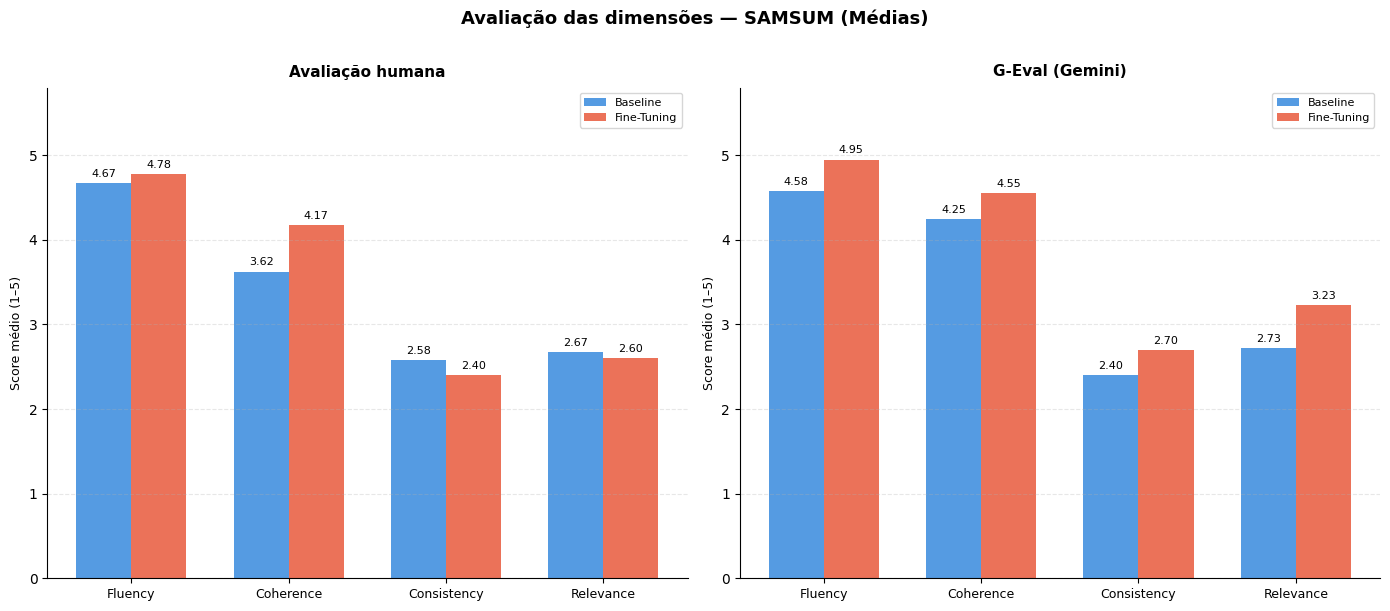

  Salvo: grafico_barras_samsum.png / .pdf


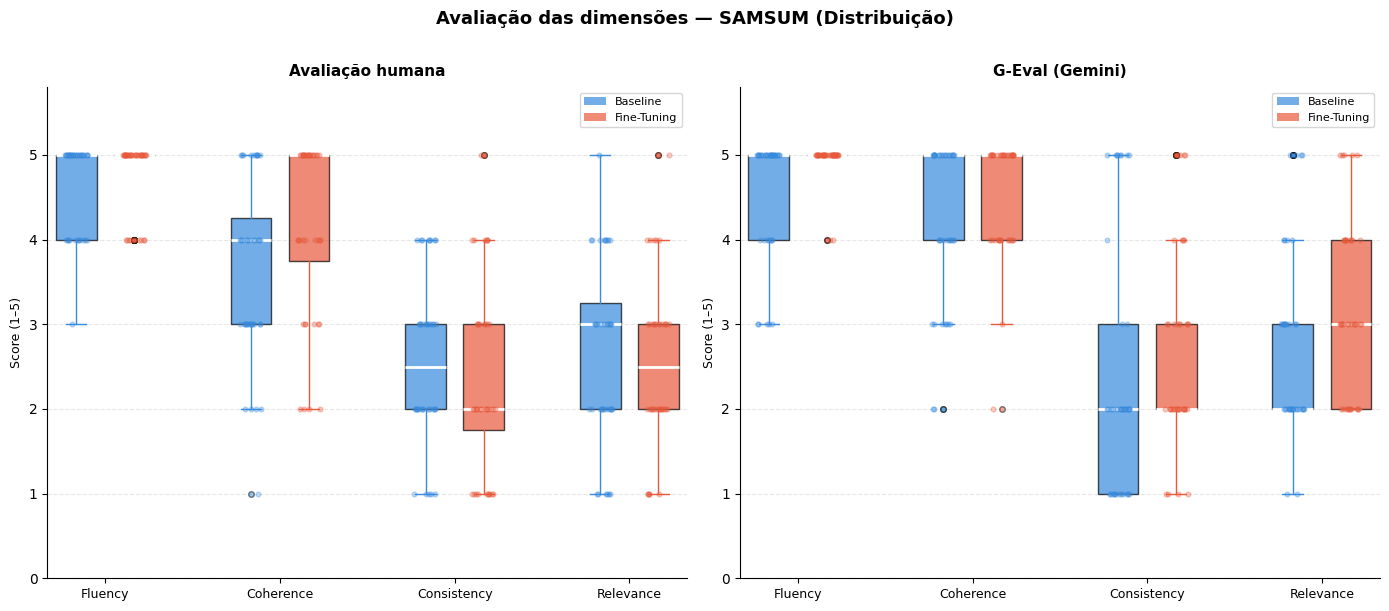

  Salvo: grafico_boxplot_samsum.png / .pdf

Processando MEDIASUM...


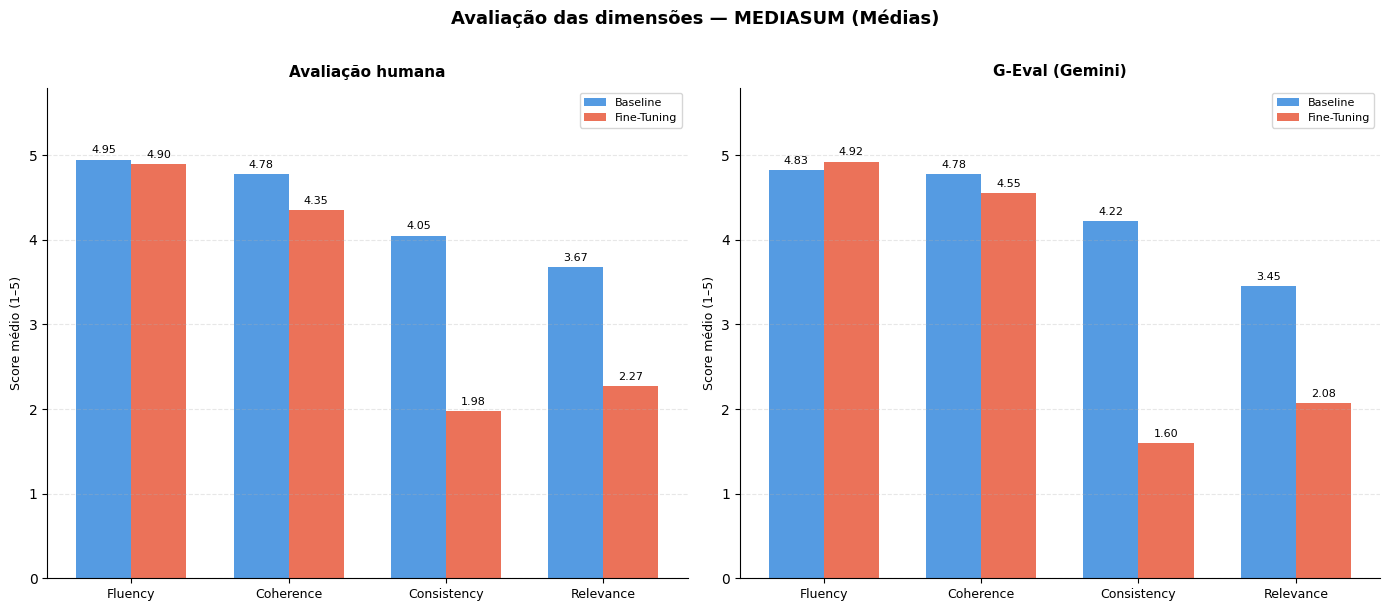

  Salvo: grafico_barras_mediasum.png / .pdf


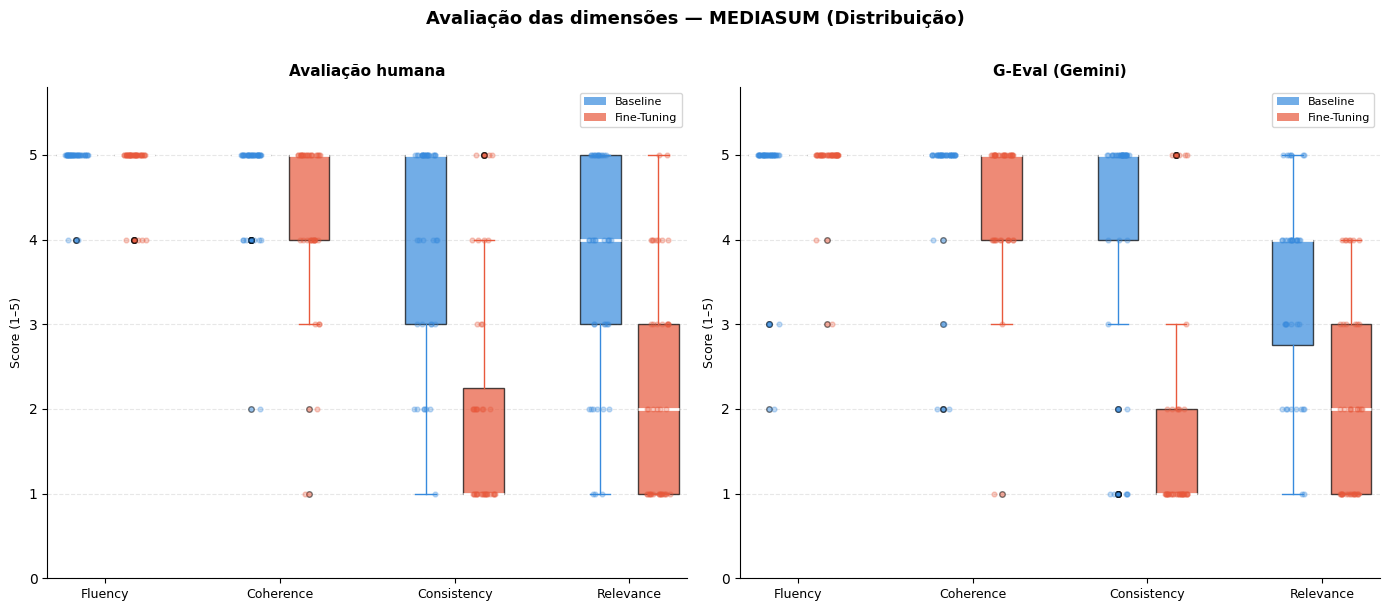

  Salvo: grafico_boxplot_mediasum.png / .pdf

Processando QMSUM...


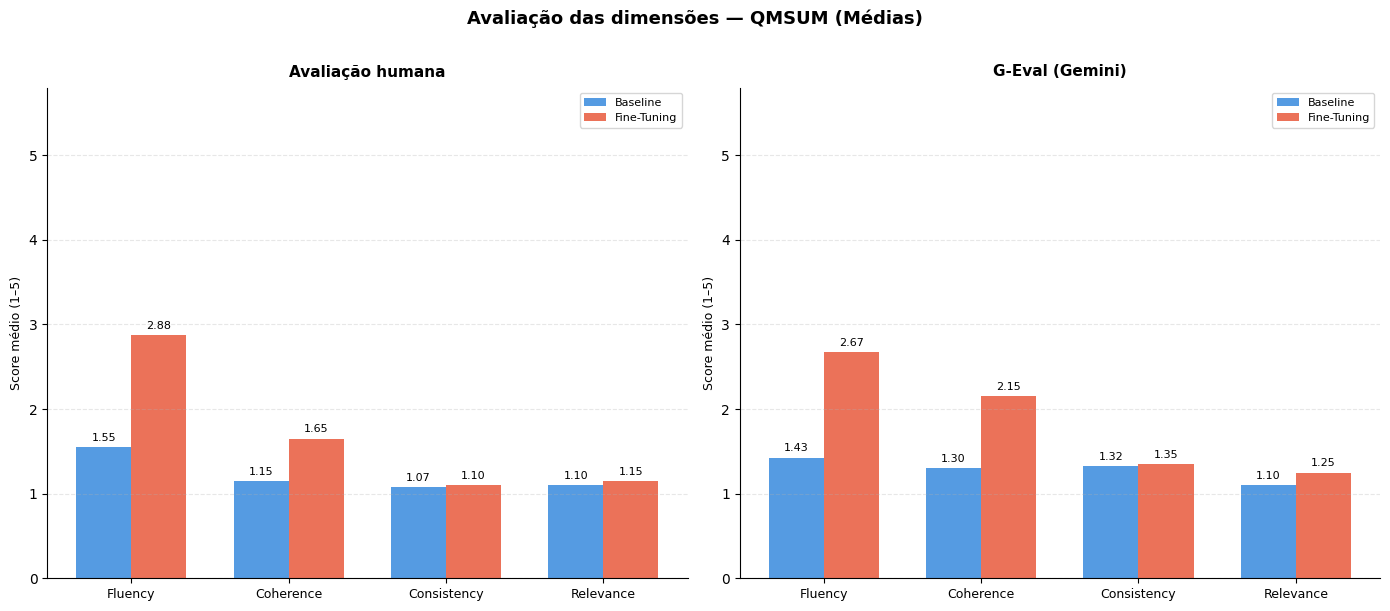

  Salvo: grafico_barras_qmsum.png / .pdf


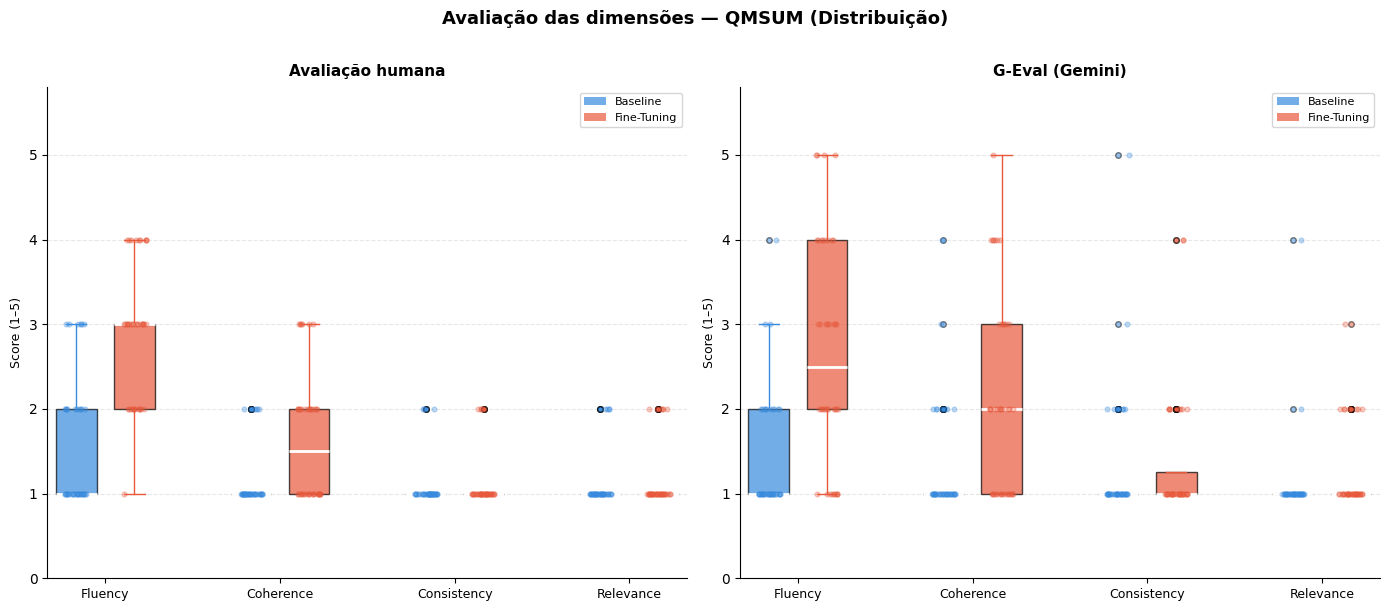

  Salvo: grafico_boxplot_qmsum.png / .pdf

Concluído!


In [4]:
# =======================================================================
# PROCESSAMENTO POR DATASET
# =======================================================================

np.random.seed(42)

for dataset in DATASETS:
    print(f"\nProcessando {dataset.upper()}...")

    pasta = os.path.join(PASTA_RAIZ, dataset)

    path_base_human = os.path.join(pasta, f"{dataset}_baseline_evaluate.csv")
    path_ft_human   = os.path.join(pasta, f"{dataset}_ft_evaluate.csv")
    path_base_geval = os.path.join(pasta, f"{dataset}_baseline_evaluate_geval.csv")
    path_ft_geval   = os.path.join(pasta, f"{dataset}_ft_evaluate_geval.csv")

    faltando = [p for p in [path_base_human, path_ft_human,
                             path_base_geval, path_ft_geval]
                if not os.path.exists(p)]
    if faltando:
        print(f"  Arquivos não encontrados: {faltando}")
        continue

    df_bh = carregar_csv(path_base_human, separador=";")
    df_fh = carregar_csv(path_ft_human,   separador=";")
    df_bg = carregar_csv(path_base_geval, separador=",")
    df_fg = carregar_csv(path_ft_geval,   separador=",")

    # Médias para barras
    medias_bh = extrair_medias(df_bh, "human_")
    medias_fh = extrair_medias(df_fh, "human_")
    medias_bg = extrair_medias(df_bg, "geval_")
    medias_fg = extrair_medias(df_fg, "geval_")

    # Valores para boxplot
    vals_bh = extrair_valores(df_bh, "human_")
    vals_fh = extrair_valores(df_fh, "human_")
    vals_bg = extrair_valores(df_bg, "geval_")
    vals_fg = extrair_valores(df_fg, "geval_")

    # =======================================================================
    # GRÁFICO 1 — Barras (médias)
    # =======================================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Avaliação das dimensões — {dataset.upper()} (Médias)",
                 fontsize=13, fontweight="bold", y=1.01)

    plotar_barras(axes[0], medias_bh, medias_fh, "Avaliação humana")
    plotar_barras(axes[1], medias_bg, medias_fg, "G-Eval (Gemini)")

    plt.tight_layout()
    nome = os.path.join(pasta, f"grafico_barras_{dataset}")
    plt.savefig(f"{nome}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{nome}.pdf", bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Salvo: grafico_barras_{dataset}.png / .pdf")

    # =======================================================================
    # GRÁFICO 2 — Boxplot (distribuição)
    # =======================================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Avaliação das dimensões — {dataset.upper()} (Distribuição)",
                 fontsize=13, fontweight="bold", y=1.01)

    plotar_boxplot(axes[0], vals_bh, vals_fh, "Avaliação humana")
    plotar_boxplot(axes[1], vals_bg, vals_fg, "G-Eval (Gemini)")

    plt.tight_layout()
    nome = os.path.join(pasta, f"grafico_boxplot_{dataset}")
    plt.savefig(f"{nome}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{nome}.pdf", bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Salvo: grafico_boxplot_{dataset}.png / .pdf")

print("\nConcluído!")
